In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_percentage_error
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, average_precision_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, precision_recall_curve
from scipy import stats
import tensorflow as tf
from keras import layers, models, optimizers, losses, metrics
from keras.preprocessing.sequence import pad_sequences
from keras.utils import to_categorical
from keras.layers import Input, Dense, Dropout, LSTM, Embedding, Flatten, LayerNormalization
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, Model

In [130]:
df = pd.read_csv('dummy_data/cleaned_data.csv')

In [131]:
df.head()

,subject_id,hadm_id,admission_type,admission_location,insurance,language,marital_status,race,hospital_expire_flag,ccs_seq,...,hour_cos,dow_sin,dow_cos,mon_sin,mon_cos,admission_index,days_since_prev_admission,days_since_first_admission,num_prior_admissions,has_prior_admission
0,10000690,26504700,EW EMER.,EMERGENCY ROOM,Medicare,English,WIDOWED,WHITE,0,"['CIR019', 'CIR019', 'CIR019', 'CIR003', 'CIR0...",...,8.660254e-01,-0.433884,-0.900969,1.224647e-16,-1.000000e+00,0,0.000000,0.000000,0,0
1,10000690,23280645,EW EMER.,EMERGENCY ROOM,Medicare,English,WIDOWED,WHITE,0,"['CIR019', 'CIR019', 'RSP002', 'CIR017', 'END0...",...,2.588190e-01,0.974928,-0.222521,-8.660254e-01,-5.000000e-01,1,71.170833,75.709722,1,1
2,10000690,25860671,EW EMER.,EMERGENCY ROOM,Medicare,English,WIDOWED,WHITE,0,"['RSP010', 'CIR019', 'RSP012', 'RSP012', 'GEN0...",...,-1.836970e-16,0.000000,1.000000,-8.660254e-01,5.000000e-01,2,39.175000,122.636111,2,1
3,10000690,26146595,EW EMER.,EMERGENCY ROOM,Medicare,English,WIDOWED,WHITE,0,"['DIG012', 'DIG012', 'DIG012', 'GEN002', 'CIR0...",...,9.659258e-01,-0.433884,-0.900969,0.000000e+00,1.000000e+00,3,442.413194,574.870833,3,1
4,10001919,29897682,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,Private,English,MARRIED,OTHER,0,"['NEO013', 'NEO070', 'CIR033', 'DIG024', 'XXX0...",...,1.000000e+00,0.433884,-0.900969,1.000000e+00,6.123234e-17,0,0.000000,0.000000,0,0


In [132]:
# Assume df has columns: subject_id, admission_index, los, mort, ...
df = df.sort_values(['subject_id', 'admission_index'])

# Shift LOS and mortality within each patient
df['prev_los']  = df.groupby('subject_id')['admission_duration'].shift(1).fillna(0)
df['prev_mort'] = df.groupby('subject_id')['hospital_expire_flag'].shift(1).fillna(0)

In [133]:
# 1) Make a missingness indicator (0/1)
df["ed_duration_missing"] = df["ed_duration"].isna().astype(np.float32)

# 2) Impute a constant that is neutral + safe for later scaling
#    (constant imputation avoids leakage since it doesn't use any split statistics)
df["ed_duration"] = df["ed_duration"].fillna(0.0)

# 3) (Optional) Clean obvious errors and cap outliers
#    - negative durations -> 0
df.loc[df["ed_duration"] < 0, "ed_duration"] = 0.0
#    - cap extreme values to reduce the chance of exploding scales later
cap = df["ed_duration"].quantile(0.999)  # very high cap
df["ed_duration"] = np.clip(df["ed_duration"], 0.0, cap)

# 4) (Optional) If you plan to log-transform, make it log-safe
# df["ed_duration_log1p"] = np.log1p(df["ed_duration"])

In [134]:
df.fillna({'ccs_seq_len': 0}, inplace=True)

In [135]:
CATEGORICAL = ['admission_type', 'admission_location', 'insurance', 'language', 'marital_status', 'race', 'gender']

NUMERIC = ['prev_los', 'prev_mort', 'ed_duration','age_at_admission', 'hour_sin', 'hour_cos',
                 'dow_sin', 'dow_cos', 'mon_sin', 'mon_cos', 'days_since_prev_admission',
                 'days_since_first_admission', 'ccs_seq_len',
                 'admission_index', 'num_prior_admissions']

BINARY = ['has_prior_admission', 'is_weekend', 'is_night_admit', 'ed_duration_missing']

In [136]:
import ast
df.fillna({'ccs_seq': '[]'}, inplace=True)
df['ccs_seq'] = df['ccs_seq'].apply(ast.literal_eval)


In [137]:
#df.fillna(0, inplace=True)  # simple imputation
df.isnull().sum()

subject_id                      0
hadm_id                         0
admission_type                  0
admission_location              0
insurance                     214
language                       13
marital_status                310
race                            0
hospital_expire_flag            0
ccs_seq                         0
ccs_seq_len                     0
gender                          0
anchor_year_group               0
admission_duration              0
ed_duration                     0
age_at_admission                0
is_weekend                      0
is_night_admit                  0
hour_sin                        0
hour_cos                        0
dow_sin                         0
dow_cos                         0
mon_sin                         0
mon_cos                         0
admission_index                 0
days_since_prev_admission       0
days_since_first_admission      0
num_prior_admissions            0
has_prior_admission             0
prev_los      

In [138]:
df.head()

,subject_id,hadm_id,admission_type,admission_location,insurance,language,marital_status,race,hospital_expire_flag,ccs_seq,...,mon_sin,mon_cos,admission_index,days_since_prev_admission,days_since_first_admission,num_prior_admissions,has_prior_admission,prev_los,prev_mort,ed_duration_missing
0,10000690,26504700,EW EMER.,EMERGENCY ROOM,Medicare,English,WIDOWED,WHITE,0,"[CIR019, CIR019, CIR019, CIR003, CIR003, SYM01...",...,1.224647e-16,-1.000000e+00,0,0.000000,0.000000,0,0,0.000000,0.0,0.0
1,10000690,23280645,EW EMER.,EMERGENCY ROOM,Medicare,English,WIDOWED,WHITE,0,"[CIR019, CIR019, RSP002, CIR017, END011, CIR01...",...,-8.660254e-01,-5.000000e-01,1,71.170833,75.709722,1,1,4.538889,0.0,0.0
2,10000690,25860671,EW EMER.,EMERGENCY ROOM,Medicare,English,WIDOWED,WHITE,0,"[RSP010, CIR019, RSP012, RSP012, GEN002, DIG02...",...,-8.660254e-01,5.000000e-01,2,39.175000,122.636111,2,1,7.751389,0.0,0.0
3,10000690,26146595,EW EMER.,EMERGENCY ROOM,Medicare,English,WIDOWED,WHITE,0,"[DIG012, DIG012, DIG012, GEN002, CIR019, NVS01...",...,0.000000e+00,1.000000e+00,3,442.413194,574.870833,3,1,9.821528,0.0,0.0
4,10001919,29897682,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,Private,English,MARRIED,OTHER,0,"[NEO013, NEO070, CIR033, DIG024, XXX000, XXX00...",...,1.000000e+00,6.123234e-17,0,0.000000,0.000000,0,0,0.000000,0.0,1.0


In [139]:
# Collapse to patient-level labels
patient_labels = (
    df.groupby("subject_id")["hospital_expire_flag"]
      .max()  # if any admission flagged death, mark as 1
      .reset_index()
)

X = patient_labels["subject_id"]
y = patient_labels["hospital_expire_flag"]

# Stratified split by patient_id and label
train_ids, test_ids, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # ensures same proportion of outcome classes
)

# Assign admissions back to splits
train_df = df[df["subject_id"].isin(train_ids)]
test_df  = df[df["subject_id"].isin(test_ids)]

print(train_df.shape, test_df.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(9577, 32) (2251, 32)
hospital_expire_flag
0    0.94525
1    0.05475
Name: proportion, dtype: float64
hospital_expire_flag
0    0.945
1    0.055
Name: proportion, dtype: float64


In [140]:
ordered_train_df = train_df.sort_values(['subject_id', 'admission_index'])
y_train_mort_indexed = ordered_train_df.groupby('subject_id')['hospital_expire_flag'].last().astype(int)
y_train_los_indexed = ordered_train_df.groupby('subject_id')['admission_duration'].last().astype("float32")

ordered_test_df = test_df.sort_values(['subject_id', 'admission_index'])
y_test_mort_indexed = ordered_test_df.groupby('subject_id')['hospital_expire_flag'].last().astype(int)
y_test_los_indexed = ordered_test_df.groupby('subject_id')['admission_duration'].last().astype("float32")
ordered_df = df.sort_values(['subject_id', 'admission_index'])
y_los_indexed = df.groupby('subject_id')['admission_duration'].last().astype("float32")

In [141]:
train_df.shape

(9577, 32)

In [142]:
test_df.shape

(2251, 32)

In [143]:
### functions to encode variables ###
class CatEncoder:
    def __init__(self):
        self.to_id = {"<PAD>": 0, "<UNK>": 1}
        self.from_id = ["<PAD>", "<UNK>"]

    def fit(self, values: pd.Series):
        for v in values.fillna("<UNK>").astype(str).unique():
            if v not in self.to_id and v != "<PAD>":
                self.to_id[v] = len(self.from_id)
                self.from_id.append(v)
        return self

    def transform(self, values: pd.Series) -> np.ndarray:
        vals = values.fillna("<UNK>").astype(str).values
        return np.array([self.to_id.get(v, 1) for v in vals], dtype="int32")  # map unknowns to 1

    def vocab_size(self):
        return len(self.from_id)

In [144]:
train_df = train_df.copy()
test_df  = test_df.copy()

# CATEGORICAL (embedding IDs)
for i in CATEGORICAL:
    categorical_enc = CatEncoder().fit(train_df[i])
    train_df.loc[:,i] = categorical_enc.transform(train_df[i])
    test_df.loc[:,i] = categorical_enc.transform(test_df[i])

# NUMERICAL (scaling)
scaler = StandardScaler().fit(train_df[NUMERIC])
train_df.loc[:, NUMERIC] = scaler.transform(train_df[NUMERIC])
test_df.loc[:, NUMERIC]  = scaler.transform(test_df[NUMERIC])

C:\Users\amydu\AppData\Local\Temp\ipykernel_19416\979772798.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 1.36941544  1.36941544  1.36941544 ...  0.96260707  0.09813928
 -0.8680306 ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train_df.loc[:, NUMERIC] = scaler.transform(train_df[NUMERIC])
C:\Users\amydu\AppData\Local\Temp\ipykernel_19416\979772798.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.40147304 -0.28309171 -0.16471038 ... -0.28309171 -0.40147304
 -0.40147304]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train_df.loc[:, NUMERIC] = scaler.transform(train_df[NUMERIC])
C:\Users\amydu\AppData\Local\Temp\ipykernel_19416\979772798.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error

In [145]:
train_df.isnull().sum().sort_values(ascending=False)

subject_id                    0
hadm_id                       0
admission_type                0
admission_location            0
insurance                     0
language                      0
marital_status                0
race                          0
hospital_expire_flag          0
ccs_seq                       0
ccs_seq_len                   0
gender                        0
anchor_year_group             0
admission_duration            0
ed_duration                   0
age_at_admission              0
is_weekend                    0
is_night_admit                0
hour_sin                      0
hour_cos                      0
dow_sin                       0
dow_cos                       0
mon_sin                       0
mon_cos                       0
admission_index               0
days_since_prev_admission     0
days_since_first_admission    0
num_prior_admissions          0
has_prior_admission           0
prev_los                      0
prev_mort                     0
ed_durat

In [146]:
# Explode list-like column into individual codes
train_codes = (
    train_df['ccs_seq']
    .explode()
    .dropna()                     # remove NaN
    .astype(str)                  # ensure all are strings
    .unique()
)

test_codes = (
    test_df['ccs_seq']
    .explode()
    .dropna()
    .astype(str)
    .unique()
)

# Build vocab from TRAIN only
unique_codes = sorted(set(train_codes))

# Add PAD and UNK
code2idx = {code: idx+2 for idx, code in enumerate(unique_codes)}
code2idx["<PAD>"] = 0 ##for padding up to max length
code2idx["<UNK>"] = 1 ##for any unknown codes in test set

#convert each code to integer ID, use UNK for any unknown codes
#outputs a list of integer IDs for each admission diagnosis sequence
def encode_sequence(seq, mapping):
    return [mapping.get(str(c), mapping["<UNK>"]) for c in seq if c is not None]

#longest sequence in data
max_len = 568

#convert ccs seq to integers
train_df["ccs_encoded"] = train_df["ccs_seq"].apply(lambda x: encode_sequence(x, code2idx))
#pad sequences to max length with 0s
train_df["diag_seq"] = pad_sequences(train_df["ccs_encoded"], maxlen=max_len, padding="post").tolist()

#apply to test df
test_df["ccs_encoded"] = test_df["ccs_seq"].apply(lambda x: encode_sequence(x, code2idx))
test_df["diag_seq"] = pad_sequences(test_df["ccs_encoded"], maxlen=max_len, padding="post").tolist()


In [147]:
#drop old columns
train_df.drop(columns=["ccs_seq", "ccs_encoded"], inplace=True)
test_df.drop(columns=["ccs_seq", "ccs_encoded"], inplace=True)

In [148]:
def to_array_int(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return np.empty((0,), dtype=np.int32)
    if isinstance(x, np.ndarray):
        return x.astype(np.int32)
    if isinstance(x, (list, tuple)):
        return np.asarray(x, dtype=np.int32)
    try:
        return np.asarray([x], dtype=np.int32)
    except Exception:
        return np.empty((0,), dtype=np.int32)


train_df["diag_seq"] = train_df["diag_seq"].apply(to_array_int)
test_df["diag_seq"]  = test_df["diag_seq"].apply(to_array_int)

In [149]:
import numpy as np
import pandas as pd
from typing import List, Tuple, Dict, Any

def _pad_3d_rows(rows: List[np.ndarray], T: int, inner_shape: Tuple[int, ...], pad_value: float = 0.0) -> np.ndarray:
    """
    Rows are arrays with shape inner_shape (e.g., (E,) or (L,E)).
    Return (T, *inner_shape) padded with pad_value.
    """
    out = np.full((T,) + inner_shape, pad_value, dtype=np.float32)
    L = min(len(rows), T)
    for t in range(L):
        a = rows[t]
        slices = tuple(slice(0, min(a.shape[d], inner_shape[d])) for d in range(len(inner_shape)))
        out[(t,)+slices] = a[slices]
    return out

def build_patient_tensors(
    df: pd.DataFrame,
    patient_col: str,
    order_col: str,
    cat_cols: List[str],
    num_cols: List[str],
    binary_cols: List[str],
    diag_col: str,
    max_T: int = None,
    pad_value: float = 0.0,
) -> Dict[str, Any]:
    """
    Returns:
      - X_cat:        (N, T, Kc)  int32
      - X_num:        (N, T, Kn)  float32
      - X_diag:       (N, T, *diag_shape) float32
      - mask_time:    (N, T)  float32 (1=real admission, 0=pad)
      - patients:     (N,) list of patient ids (order matches tensors)
      - hadm_ids:     (N, T) object array of admission IDs (optional, if present in df)
    """
    # Ensure lists
    cat_cols = list(cat_cols)
    num_cols = list(num_cols)   
    binary_cols = list(binary_cols)

    # Ascending order per patient
    df_sorted = df.sort_values([patient_col, order_col]).copy()

    # Infer diagnosis embedding shape from first non-null row
    first_non_null = next((v for v in df_sorted[diag_col].values if isinstance(v, np.ndarray)), None)
    diag_shape = first_non_null.shape
    diag_is_int = np.issubdtype(first_non_null.dtype, np.integer)

    # Group by patient
    groups = list(df_sorted.groupby(patient_col, sort=False))

    # Compute T
    lengths = [len(g) for _, g in groups]
    T = max(lengths) if max_T is None else int(max_T)   # always use max_T when given
    N = len(groups)

    Kc = len(cat_cols)
    Kn = len(num_cols)
    Kb = len(binary_cols)

    X_cat  = np.zeros((N, T, Kc), dtype="int32")
    X_num  = np.zeros((N, T, Kn), dtype="float32")
    X_bin  = np.zeros((N, T, Kb), dtype="float32")
    X_diag = np.full((N, T) + diag_shape, 0 if diag_is_int else pad_value, dtype="int32" if diag_is_int else "float32")
    mask   = np.zeros((N, T), dtype="float32")
    hadm   = np.empty((N, T), dtype=object) if "hadm_id" in df.columns else None

    patients = []

    for i, (pid, g) in enumerate(groups):
        patients.append(pid)

        # Within-patient arrays
        cat_rows = g[cat_cols].to_numpy(dtype="int32") if Kc > 0 else None  # (len_g, Kc)
        num_rows = g[num_cols].to_numpy(dtype="float32") if Kn > 0 else None
        bin_rows = g[binary_cols].to_numpy(dtype="float32") if Kb > 0 else None
        diag_rows = g[diag_col].tolist()  # list of np arrays

        L = min(len(g), T)

        # Fill mask
        mask[i, :L] = 1.0

        # Fill hadm ids if available
        if hadm is not None:
            vals = g["hadm_id"].tolist()
            hadm[i, :L] = vals[:L]

        # Categorical / numeric
        if Kc > 0:
            # pad (T, Kc)
            tmp = np.zeros((T, Kc), dtype="int32")
            if L > 0:
                tmp[:L, :] = cat_rows[:L, :]
            X_cat[i] = tmp

        if Kn > 0:
            tmp = np.zeros((T, Kn), dtype="float32")
            if L > 0:
                tmp[:L, :] = num_rows[:L, :]
            X_num[i] = tmp
        
        if Kb > 0:
            tmp = np.zeros((T, Kb), dtype="float32")
            if L > 0:
                tmp[:L, :] = bin_rows[:L, :]
            X_bin[i] = tmp

        # Diagnosis embedding per admission (shape diag_shape)
        X_diag[i] = _pad_3d_rows(diag_rows, T, diag_shape, pad_value=pad_value)

    out = {
        "X_cat": X_cat,            # (N, T, Kc)
        "X_num": X_num,            # (N, T, Kn)
        "X_bin": X_bin,            # (N, T, Kb)
        "X_diag": X_diag,          # (N, T, *diag_shape)
        "mask_time": mask,         # (N, T)
        "patients": np.array(patients),
    }
    if hadm is not None:
        out["hadm_ids"] = hadm
    return out


In [150]:
train_tensor = build_patient_tensors(
    train_df,
    patient_col="subject_id",
    order_col="admission_index",
    cat_cols=CATEGORICAL,
    num_cols=NUMERIC,
    binary_cols=BINARY,
    diag_col="diag_seq",
    max_T=101,
    pad_value=0.0,
)

In [151]:
X_cat_train     = train_tensor["X_cat"]       # (N, T, Kc)
X_num_train     = train_tensor["X_num"]       # (N, T, Kn)
X_bin_train     = train_tensor["X_bin"]       # (N, T, Kb)
X_diag_train    = train_tensor["X_diag"]      # (N, T, E) or (N, T, L, E)
mask_time_train = train_tensor["mask_time"]   # (N, T)
patients_train  = train_tensor["patients"]    # (N,)

In [152]:
test_tensor = build_patient_tensors(
    test_df,
    patient_col="subject_id",
    order_col="admission_index",
    cat_cols=CATEGORICAL,
    binary_cols=BINARY,
    num_cols=NUMERIC,
    diag_col="diag_seq",
    max_T=101,
    pad_value=0.0,
)

X_cat_test      = test_tensor["X_cat"]        # (N, T, Kc)
X_num_test      = test_tensor["X_num"]        # (N, T, Kn)
X_diag_test     = test_tensor["X_diag"]       # (N, T, *diag_shape)
X_bin_test      = test_tensor["X_bin"]        # (N, T, Kb)
mask_time_test  = test_tensor["mask_time"]    # (N, T)
patients_test   = test_tensor["patients"]     # (N,)

In [153]:
train_patients = train_tensor["patients"]
test_patients = test_tensor["patients"]
y_train_los = y_train_los_indexed.reindex(patients_train).astype("float32").to_numpy()
y_test_los = y_test_los_indexed.reindex(patients_test).astype("float32").to_numpy()
y_train_mort = y_train_mort_indexed.reindex(patients_train).astype(int).to_numpy()
y_test_mort = y_test_mort_indexed.reindex(patients_test).astype(int).to_numpy()

In [154]:
y_train_los_log = np.log1p(y_train_los)   # log(1 + LOS)
y_test_los_log  = np.log1p(y_test_los)

In [155]:
X_bin_test.shape

(1000, 101, 4)

In [156]:
import keras
keras.backend.clear_session()


In [157]:
vocab_sizes = [CatEncoder().fit(train_df[c]).vocab_size() for c in CATEGORICAL]

C:\Users\amydu\AppData\Local\Temp\ipykernel_19416\2205639023.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  for v in values.fillna("<UNK>").astype(str).unique():
C:\Users\amydu\AppData\Local\Temp\ipykernel_19416\2205639023.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  for v in values.fillna("<UNK>").astype(str).unique():
C:\Users\amydu\AppData\Local\Temp\ipykernel_19416\2205639023.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=Fal

In [158]:
import tensorflow as tf
from keras import layers, Model
from keras.initializers import Constant
import numpy as np
import keras
from keras import ops
from keras import ops
from keras.saving import register_keras_serializable
from typing import List, Optional



keras.backend.clear_session()

# ---- Small reusable blocks ----

@register_keras_serializable(package="custom")
class CatEmbeddings(layers.Layer):
    """Slices Kc categorical features and embeds each, then concatenates -> (B,T,Kc*d)."""
    def __init__(self, vocab_sizes, d=8, name="cat_embed_block"):
        super().__init__(name=name)
        self.vocab_sizes = vocab_sizes
        self.d = d
        self.embs = [layers.Embedding(input_dim=V, output_dim=d, mask_zero=True, name=f"emb_cat_{j}")
                    for j, V in enumerate(vocab_sizes)]

    def call(self, x):  # x: (B,T,Kc) int32
        parts = []
        for j, emb in enumerate(self.embs):
            xj = x[..., j]              # (B,T)
            ej = emb(xj)                # (B,T,d)
            parts.append(ej)
        return parts[0] if len(parts) == 1 else tf.concat(parts, axis=-1)  # (B,T,Kc*d)
    
# ---Transformer and Attention Blocks---

# ---------- Hyperparameters ----------
d_model    = 128        # must match/approx your X's last dim (or project to this)
num_heads  = 8
ff_dim     = 256
drop_rate  = 0.1
num_layers = 3
T_max      = 101        # your max sequence length (pad length)

# ---------- Positional embedding (learned) ----------
@register_keras_serializable(package="custom")
class PositionalEmbedding(layers.Layer):
    def __init__(self, maxlen, d_model):
        super().__init__()
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=d_model)

    def call(self, x):
        # x: (B, T, D)
        T = tf.shape(x)[1]
        pos = tf.range(start=0, limit=T, delta=1)
        pos = self.pos_emb(pos)           # (T, D)
        return x + pos[None, :, :]        # broadcast to (B, T, D)

# ---------- Transformer Encoder Block ----------
@register_keras_serializable(package="custom")
class TransformerBlock(layers.Layer):
    def __init__(self, d_model, num_heads, ff_dim, drop_rate=0.1):
        super().__init__()
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.mha   = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model, dropout=drop_rate)
        self.drop1 = layers.Dropout(drop_rate)

        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.ffn   = tf.keras.Sequential([
            layers.Dense(ff_dim, activation="gelu"),
            layers.Dropout(drop_rate),
            layers.Dense(d_model),
        ])
        self.drop2 = layers.Dropout(drop_rate)

    def call(self, x, attn_mask, training=False):
        # x: (B, T, D), attn_mask: (B, T, T) boolean – True means keep/attend
        h = self.norm1(x)
        h = self.mha(h, h, attention_mask=attn_mask, training=training)   # (B, T, D)
        x = x + self.drop1(h, training=training)

        h = self.norm2(x)
        h = self.ffn(h, training=training)
        return x + self.drop2(h, training=training)

# ---- Inputs ----
T, Kc, Kn, Kb, E = X_cat_train.shape[1], X_cat_train.shape[2], X_num_train.shape[2], X_bin_train.shape[2], X_diag_train.shape[2]
inp_cat  = layers.Input(shape=(T, Kc), dtype="int32",   name="cat_in")
inp_num  = layers.Input(shape=(T, Kn), dtype="float32", name="num_in")
inp_bin  = layers.Input(shape=(T, Kb), dtype="float32", name="bin_in")
inp_mask = layers.Input(shape=(T,),    dtype="bool",    name="mask_in")   # <- bool directly

# add diagnosis input with masking 
vocab_size = len(code2idx)          # ensure PAD=0, UNK=1 in your mapping
d_diag = 8
inp_diag = layers.Input(shape=(None, max_len), dtype="int32", name="diag_in")
# Inner-token embedding with automatic mask on zeros:
emb_tokens = layers.Embedding(vocab_size, d_diag, mask_zero=True, name="diag_token_emb")(inp_diag)  # (B,T,L,d)

# Compute masked mean over the inner L dimension to get one vector per admission
inner_mask = emb_tokens._keras_mask                            # (B,T,L) boolean
inner_mask_f = ops.expand_dims(ops.cast(inner_mask, emb_tokens.dtype), axis=-1)  # (B,T,L,1)
sum_emb = ops.sum(emb_tokens * inner_mask_f, axis=2)      # (B,T,d)
cnt_emb = ops.sum(inner_mask_f, axis=2)                   # (B,T,1)
diag_per_adm = sum_emb / ops.maximum(cnt_emb, ops.convert_to_tensor(1e-9, dtype=sum_emb.dtype)) 

# Derive a time-step mask from inner tokens (an admission is valid if it has any non-pad token)
time_mask_from_diag = ops.any(inner_mask, axis=2)  # (B,T) bool
time_mask = ops.logical_and(inp_mask, time_mask_from_diag)

# ---- Categorical embeddings ----
cat_emb = CatEmbeddings(vocab_sizes, d=8)(inp_cat)            # (B,T,Kc*d)

# ---- Fuse modalities ----
fusion = layers.Concatenate(name="visit_fusion")([cat_emb, inp_num, inp_bin, diag_per_adm])  # (B,T,D)

# (Optional) project to d_model if D != d_model
x = fusion
if x.shape[-1] != d_model:
    x = layers.Dense(d_model, name="proj_to_dmodel")(x)

# positional embedding
embed = PositionalEmbedding(T_max, d_model)(x)  # (B,T,D)

# Build (B,T,T) attention mask from your (B,T) time_mask
attn_mask = ops.logical_and(time_mask[:, :, None], time_mask[:, None, :])  # True=keep

for _ in range(num_layers):
    transformer = TransformerBlock(d_model, num_heads, ff_dim, drop_rate)(embed, attn_mask)
H = transformer  # (B,T,d_model) encoder outputs

# --- (D) Masked mean pooling -> (B, D) ---
m = ops.cast(time_mask, "float32")[..., None]                # (B, T, 1)
pooled = ops.sum(H * m, axis=1) / (ops.sum(m, axis=1) + 1e-6)# (B, D)

# ---- Trunk ----
z = layers.LayerNormalization(epsilon=1e-6, name="trunk_ln")(pooled)
z = layers.Dense(128, activation="relu", name="trunk_dense")(z)
z = layers.Dropout(0.3, name="trunk_drop")(z)

# ---- Heads ----
pos = y_train_mort.mean()
init_bias = np.log(pos / (1. - pos + 1e-12))
mortality = layers.Dense(1, activation="sigmoid", name="mortality",
                         bias_initializer=Constant(init_bias))(z)
los = layers.Dense(1, activation="linear", name="los")(z)

model = Model(
    inputs={"cat_in": inp_cat, "num_in": inp_num, "bin_in": inp_bin, "diag_in": inp_diag, "mask_in": inp_mask},
    outputs={"mortality": mortality, "los": los},
    name="multimodal_lstm_attn"
)
model.summary()



Model: "multimodal_lstm_attn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ diag_in             │ (None, None, 568) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None, 568) │          0 │ diag_in[0][0]     │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast (Cast)         │ (None, None, 568) │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diag_token_emb      │ (None, None, 568, │      3,400 │ diag_in[0][0]     │
│ (Embedding)         │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims         │ (None, None, 568, │          0 │ cast[0][0]        │
│ (ExpandDims)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, None, 568, │          0 │ diag_token_emb[0… │
│                     │ 8)                │            │ expand_dims[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sum_1 (Sum)         │ (None, None, 1)   │          0 │ expand_dims[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_in (InputLayer) │ (None, 101, 7)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sum (Sum)           │ (None, None, 8)   │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maximum (Maximum)   │ (None, None, 1)   │          0 │ sum_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_embed_block     │ (None, 101, 56)   │        824 │ cat_in[0][0]      │
│ (CatEmbeddings)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_in (InputLayer) │ (None, 101, 15)   │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bin_in (InputLayer) │ (None, 101, 4)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ true_divide         │ (None, None, 8)   │          0 │ sum[0][0],        │
│ (TrueDivide)        │                   │            │ maximum[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mask_in             │ (None, 101)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, None)      │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ visit_fusion        │ (None, 101, 83)   │          0 │ cat_embed_block[… │
│ (Concatenate)       │                   │            │ num_in[0][0],     │
│                     │                   │            │ bin_in[0][0],     │
│                     │                   │            │ true_divide[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logical_and         │ (None, 101)       │          0 │ mask_in[0][0],    │
│ (LogicalAnd)        │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ proj_to_dmodel      │ (None, 101, 128)  │     10,752 │ visit_fusion[0][

 Total params: 638,850 (2.44 MB)

 Trainable params: 638,850 (2.44 MB)

 Non-trainable params: 0 (0.00 B)

sw_mort shape: (4000,) unique values: [ 1.       17.264841]
sw_los shape: (4000,) unique values: [1.]
Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - los_loss: 1.4861 - los_mae: 0.9350 - los_mse: 1.4894 - loss: 4.4087 - mortality_accuracy: 0.7778 - mortality_auc: 0.6914 - mortality_loss: 1.4563 - mortality_pr_auc: 0.1170 - mortality_precision: 0.1132 - mortality_recall: 0.4475 - val_los_loss: 0.5492 - val_los_mae: 0.5902 - val_los_mse: 0.5442 - val_loss: 1.6784 - val_mortality_accuracy: 0.6660 - val_mortality_auc: 0.8454 - val_mortality_loss: 0.5675 - val_mortality_pr_auc: 0.1915 - val_mortality_precision: 0.1300 - val_mortality_recall: 0.8909
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 53s 846ms/step - los_loss: 0.8605 - los_mae: 0.7326 - los_mse: 0.8638 - loss: 2.9410 - mortality_accuracy: 0.7218 - mortality_auc: 0.7952 - mortality_loss: 1.0357 - mortality_pr_auc: 0.1589 - mortality_precision: 0.1287 - mortality_recall: 0.7078 - val_los_loss: 0.5223 - val_los_mae: 0.5773 - val_los_mse

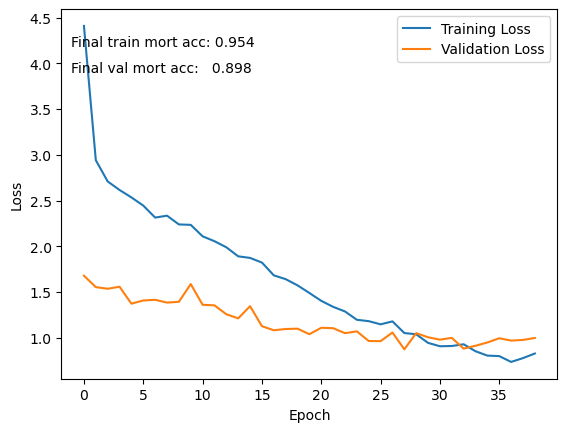

In [ ]:
# compile with multiple losses and metrics
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss={"mortality": "binary_crossentropy"},
    metrics={
        "mortality": [
            metrics.AUC(name="auc"),
            metrics.AUC(name="pr_auc", curve="PR"),
            metrics.Precision(name="precision"),
            metrics.Recall(name="recall"),
            metrics.BinaryAccuracy(name="accuracy"),
        ],
    },
    loss_weights={"mortality": 1.0},   # tune if needed
)

# counts
p = int((y_train_mort == 1).sum())
n = int((y_train_mort == 0).sum())
w_pos = n / max(p, 1)         # e.g. ~17–20 for ~5–6% positives
w_neg = 1.0

# per-sample weights for the mortality head
sw_mort = np.where(y_train_mort == 1, w_pos, w_neg).astype("float32")
#check sample weights
print("sw_mort shape:", sw_mort.shape, "unique values:", np.unique(sw_mort)[:10])               

train_inputs = {
    "cat_in":  X_cat_train,
    "num_in":  X_num_train,
    "bin_in":  X_bin_train,
    "diag_in": X_diag_train,
    "mask_in": mask_time_train.astype("float32"),
}
val_inputs = {
    "cat_in":  X_cat_test,
    "num_in":  X_num_test,
    "bin_in":  X_bin_test,
    "diag_in": X_diag_test,
    "mask_in": mask_time_test.astype("float32"),
}

es = tf.keras.callbacks.EarlyStopping(
    monitor="val_mortality_pr_auc", mode="max",
    patience=6, restore_best_weights=True
)

hist = model.fit(
    x=train_inputs,
    y={"mortality": y_train_mort},
    validation_data=(val_inputs, {"mortality": y_test_mort}),
    epochs=50,
    batch_size=64,
    callbacks=[es],
    sample_weight={"mortality": sw_mort},
    verbose=1
)

#save model
model.save('models/transformer_mort.keras')

plt.plot(hist.history['loss'], label='Training Loss')
plt.plot(hist.history['val_loss'], label='Validation Loss')
plt.legend(); plt.xlabel('Epoch'); plt.ylabel('Loss')

# If you want accuracy from the mortality head:
final_val_loss = hist.history['val_loss'][-1]
final_train_acc = hist.history.get('mortality_accuracy', [np.nan])[-1]
final_val_acc   = hist.history.get('val_mortality_accuracy', [np.nan])[-1]
plt.annotate(f'Final train mort acc: {final_train_acc:.3f}', (0.02, 0.90), xycoords='axes fraction')
plt.annotate(f'Final val mort acc:   {final_val_acc:.3f}',   (0.02, 0.83), xycoords='axes fraction')
plt.show()

[[900  45]
 [ 26  29]]


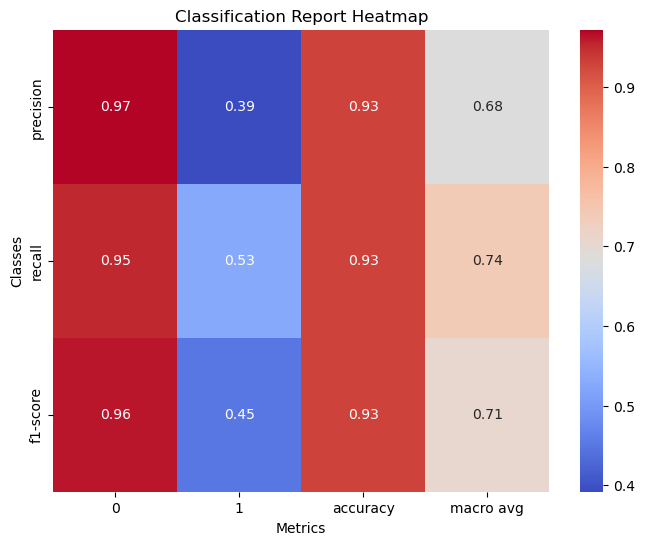

Mortality — ROC AUC: 0.9196344396344396
Mortality — PR  AUC: 0.37899116481136064
Mortality — Precision: 0.3918918918918919
Mortality — Recall   : 0.5272727272727272
Mortality — F1       : 0.4496124031007752


In [160]:
# -------- 4) Evaluation --------
#eval_out = model.evaluate(val_inputs, {"mortality": y_test_mort, "los": y_test_los}, verbose=0)
# Keras returns a flat list: [total_loss, mort_loss, los_loss, mort_auc, mort_pr_auc, ... , los_mae, los_mse]
#print("Eval:", eval_out)

# Extra: thresholded mort metrics + LOS MAE in original units (if you log-transformed, invert here)
y_prob = model.predict(val_inputs, batch_size=256, verbose=0)["mortality"].ravel()

from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, average_precision_score, accuracy_score
import seaborn as sns
from seaborn import heatmap
y_hat = (y_prob >= 0.79).astype(int)
accuracy = accuracy_score(y_test_mort, y_hat)

# Compute confusion matrix
cm = confusion_matrix(y_test_mort, y_hat)
# Display confusion matrix
print(cm)

report = classification_report(y_test_mort, y_hat, output_dict=True)
# Convert to a DataFrame
report_df = pd.DataFrame(report).iloc[:-1, :-1]  # Exclude 'accuracy' row and 'support' column

# Plot as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(report_df, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Classification Report Heatmap")
plt.ylabel("Classes")
plt.xlabel("Metrics")
plt.show()

print("Mortality — ROC AUC:", roc_auc_score(y_test_mort, y_prob))
print("Mortality — PR  AUC:", average_precision_score(y_test_mort, y_prob))
print("Mortality — Precision:", precision_score(y_test_mort, y_hat, zero_division=0))
print("Mortality — Recall   :", recall_score(y_test_mort, y_hat, zero_division=0))
print("Mortality — F1       :", f1_score(y_test_mort, y_hat, zero_division=0))

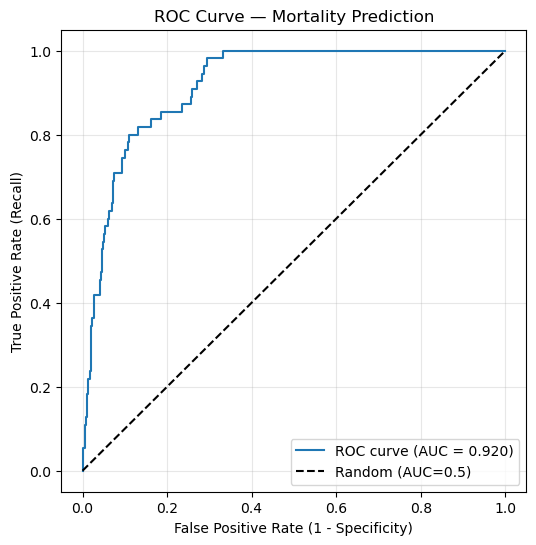

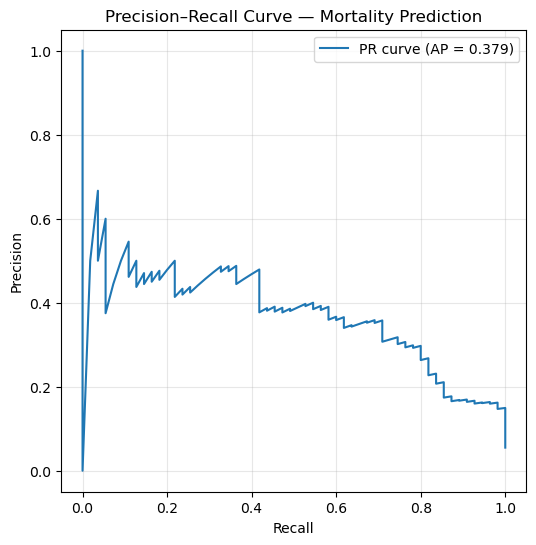

In [161]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# --- Get probabilities ---
y_prob = model.predict(val_inputs, batch_size=256, verbose=0)["mortality"].ravel()

# --- Compute ROC ---
fpr, tpr, thresholds = roc_curve(y_test_mort, y_prob)
auc_val = roc_auc_score(y_test_mort, y_prob)

# --- Plot ---
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc_val:.3f})")
plt.plot([0,1], [0,1], "k--", label="Random (AUC=0.5)")  # diagonal line
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve — Mortality Prediction")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


from sklearn.metrics import precision_recall_curve, average_precision_score

prec, rec, ths = precision_recall_curve(y_test_mort, y_prob)
ap_val = average_precision_score(y_test_mort, y_prob)

plt.figure(figsize=(6,6))
plt.plot(rec, prec, label=f"PR curve (AP = {ap_val:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve — Mortality Prediction")
plt.legend(loc="upper right")
plt.grid(alpha=0.3)
plt.show()



In [163]:
precisions, recalls, thresholds = precision_recall_curve(y_test_mort, y_prob)

Best threshold: 0.53477645 Precision: 0.3577981651376147 Recall: 0.7090909090909091 F1: 0.47560975609711514


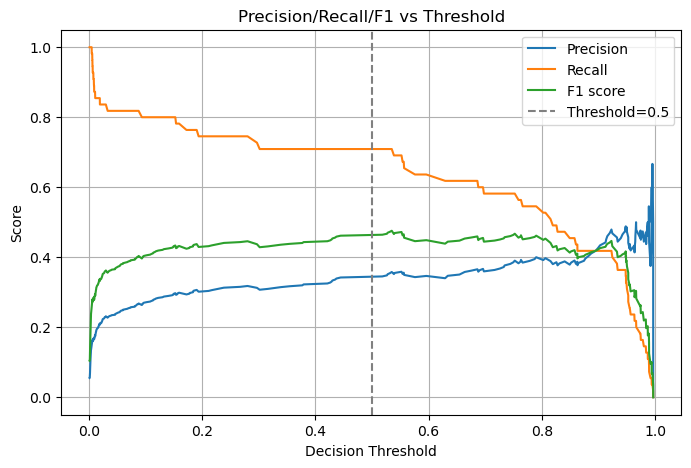

In [164]:
# pick threshold that maximizes F1
f1 = 2*precisions*recalls / (precisions+recalls+1e-12)
best_idx = f1.argmax()
print("Best threshold:", thresholds[best_idx], "Precision:", precisions[best_idx], "Recall:", recalls[best_idx], "F1:", f1[best_idx])

# plot precision, recall, and F1 vs threshold
plt.figure(figsize=(8,5))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.plot(thresholds, f1[:-1], label="F1 score")
plt.axvline(0.5, color="grey", ls="--", label="Threshold=0.5")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision/Recall/F1 vs Threshold")
plt.legend()
plt.grid(True)
plt.show()
